# L07 - Irriducibile mass of Black Holes

For a BH of mass $M$ spin $\chi\in [0,1]$, the irreducible mass is 
\begin{equation}
    M_{\rm irr} =  M \sqrt{\frac{1+\sqrt{1-\chi^2}}{2}}
\end{equation}

Let's define 
$$f(\chi) = \sqrt{\frac{1+\sqrt{1-\chi^2}}{2}}$$

- the spin $\chi$ is uniformly distributed between 0 and 1.
- the mass $M$ is normally distributed with mean $\mu$ and standard deviation $\sigma$.
- (masses and spins are uncorrelated)

In [32]:
import numpy as np
import random
import time
import matplotlib.pyplot as plt
import astropy
import sklearn
from sklearn.mixture import GaussianMixture
import scipy.stats as stats

In [33]:
def f(spin):
    return np.sqrt((1+ np.sqrt(1-spin**2))/2)

1. Start with a value of $\sigma=0.02$. ($\mu$ is a scale and not a parameter). Just set $\mu=1$ (all masses in the problem are measured in units of $\mu$).
2. Plot the resulting pdf of $M_{\rm irr}$.

In [34]:
N = 10000
sigma = 0.02
mu = 1
spin = np.random.uniform(0,1, N)
M = np.random.normal(mu, sigma, N)

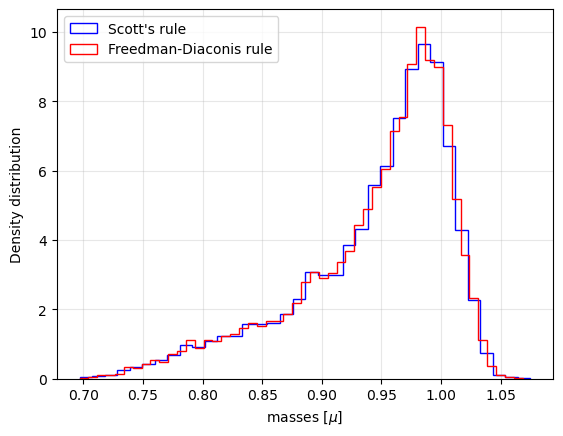

In [35]:
import astropy.visualization.hist
M_irr = M*f(spin)
astropy.visualization.hist(M_irr, bins="scott", color='blue', histtype="step",density=True, label="Scott's rule")
astropy.visualization.hist(M_irr, bins="freedman", color='red', histtype="step",density=True, label="Freedman-Diaconis rule")
plt.xlabel(r"masses [$\mu$]")
plt.ylabel("Density distribution")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

3. Using the same samples, plot the distribution of $M_{\rm irr}$ using a KDE.
4. Compute the KS distance between ${M_{\rm irr}}/\mu$ and ${f}$ as a function of $\sigma$. Discuss the limits at large and small values of $\sigma$.
5. Compute the KS distance between ${M_{\rm irr}}$ and $M$ as a function of $\sigma$. Discuss the limits at large and small values of $\sigma$.

In [36]:
from sklearn.neighbors import KernelDensity
xgrid = np.linspace(M_irr.min(), M_irr.max(),1000)

def kde_sklearn(data, bandwidth, kernel):
    kde_skl = KernelDensity(bandwidth = bandwidth, kernel=kernel)
    kde_skl.fit(data[:, np.newaxis])
    log_pdf = kde_skl.score_samples(xgrid[:, np.newaxis]) # sklearn returns log(density)
    return np.exp(log_pdf)

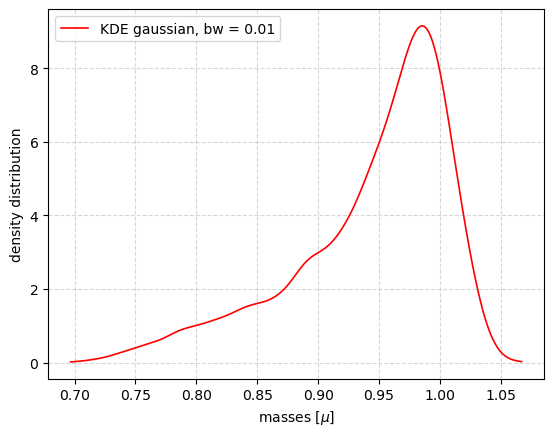

In [37]:
PDF = kde_sklearn(M_irr,bandwidth=0.01, kernel="gaussian")
plt.plot(xgrid, PDF, color='red', linewidth=1.2, label="KDE gaussian, bw = 0.01")
plt.xlabel(r"masses [$\mu$]")
plt.ylabel("density distribution")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

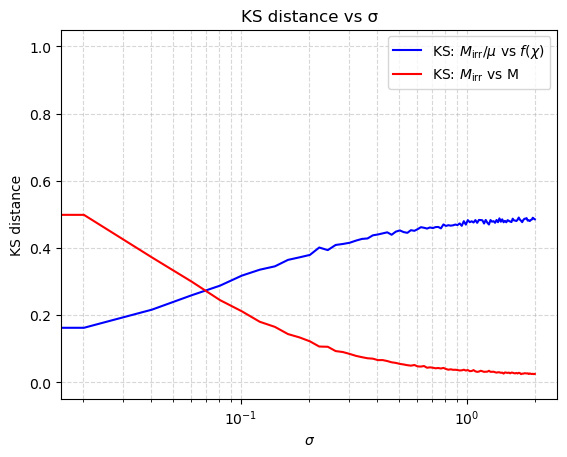

In [38]:
sigma_values = np.linspace(0, 2, 100)
ks_distances_1 = [] #between M_irr/mu and f
ks_distances_2 = [] #between M_irr and M

for sigma in sigma_values:
    M = np.random.normal(mu, sigma, N)
    M_irr = M * f(spin)
    ks_stat_1 = stats.ks_2samp(M_irr / mu, f(spin)).statistic
    ks_distances_1.append(ks_stat_1)
    ks_stat_2 = stats.ks_2samp(M_irr, M).statistic
    ks_distances_2.append(ks_stat_2)

plt.plot(sigma_values, ks_distances_1, color='blue', label=r'KS: $M_{\rm irr}/\mu$ vs $f(\chi)$')
plt.plot(sigma_values, ks_distances_2, color='red', label=r'KS: $M_{\rm irr}$ vs M')

plt.xscale('log')
plt.xlabel(r'$\sigma$')
plt.ylabel("KS distance")
plt.title("KS distance vs σ")
plt.grid(True, which="both", linestyle="--", alpha=0.5)
plt.legend()
plt.show()

For $\sigma$ << $\mu$ : ${M_{\rm irr}}$ is distributed like f 
 - Se $\sigma$ è piccolissimo la distribuzione di M è estremamente stretta attorno al suo valore medio $\mu$, quindi M si comporta quasi come una costante fissa a 1
 - In questo regime, la distribuzione delle masse ${M_{\rm irr}}$ è interamente dominata dallo spin $\chi$

For $\sigma$ >> $\mu$ : ${M_{\rm irr}}$ is distributed like M
- se $\sigma$ è grande, le masse sono distribuite in un intervallo molto ampio
- $f(\chi)$ invece può variare in un intervallo molto limitato: $$f(\chi=0) = \sqrt{\frac{1+1}{2}} = 1$$ $$f(\chi=1) = \sqrt{\frac{1}{2}} = 0.707...$$
- In questo regime, la distribuzione delle masse ${M_{\rm irr}}$ è prevalentemente dominata dalla massa M

The pdf of  𝑓  from its mathematical definition is:
$$ \pi(f) = 2\frac{2 f^2-1}{\sqrt{1 - f^2}} $$

The pdfs of $M_{\rm irr}$ from its mathematical definition is:
$$ p(M_{\rm irr})  = \frac{\sqrt{2/\pi}}{\sigma} \int_{1/\sqrt{2}}^1 \exp\left[{-\frac{(M_{\rm irr}/f -\mu)^2}{2\sigma^2}}\right]  \frac{2 f^2-1}{f \sqrt{1 - f^2}} $$
The this expression is only semi-analytic; that integral should then be solved numerically.

Plot those pdfs check that they agree with your KDE reconstructions.


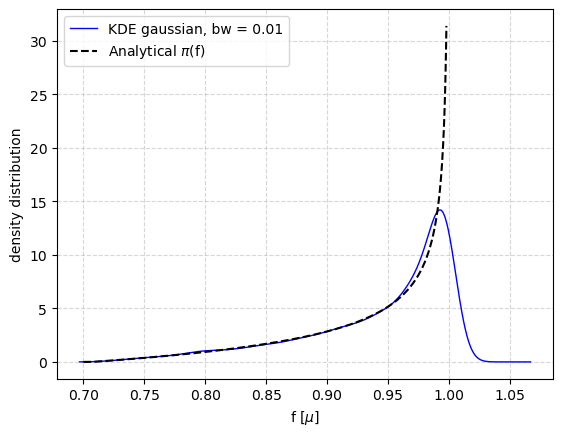

In [39]:
# mathematical definition of pdf of f

def pi(f):
    with np.errstate(divide='ignore', invalid='ignore'):
        pi = 2 * ((2 * f**2 - 1) / np.sqrt(1 - f**2))
        pi[(f < 1/np.sqrt(2)) | (f > 1)] = 0  # fuori dal dominio
    return pi

f_vals = f(spin)
#xgrid = np.linspace(M_irr.min(), M_irr.max(), 1000)
x_grid_f = np.linspace(0.7, 0.998, 1000)
kde_f = kde_sklearn(f_vals, bandwidth=0.01, kernel="gaussian")

plt.plot(xgrid, kde_f, color='blue', linewidth=1, label="KDE gaussian, bw = 0.01")
plt.plot(x_grid_f, pi(x_grid_f), label=r"Analytical $\pi$(f)", color='black',linestyle='--')
plt.xlabel(r"f [$\mu$]")
plt.ylabel("density distribution")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

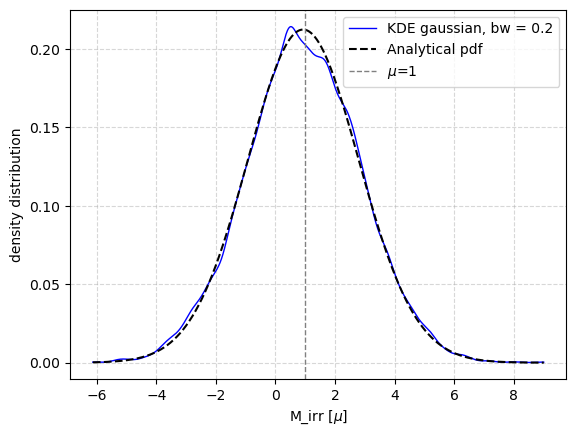

In [42]:
# mathematical definition of pdf of M_irr
from scipy.integrate import quad

def pdf_Mirr(M_irr_val, mu=1, sigma=0.02):
    def integrand(f):
        if f < 1/np.sqrt(2) or f > 1:
            return 0
        factor = (2 * f**2 - 1) / (f* np.sqrt(1 - f**2))
        exponent = -((M_irr_val / f - mu)**2) / (2 * sigma**2)
        return np.exp(exponent) * factor

    integral, _ = quad(integrand, 1/np.sqrt(2), 1)
    normalization = np.sqrt(2 / np.pi) / sigma
    return normalization * integral

M_irr = M*f(spin)
xgrid = np.linspace(M_irr.min(), M_irr.max(), 1000)
kde_Mirr = kde_sklearn(M_irr, bandwidth=0.2, kernel='gaussian')
pdf = np.array([pdf_Mirr(x, mu=mu, sigma=sigma) for x in xgrid])

plt.plot(xgrid, kde_Mirr, color='blue', linewidth=1, label="KDE gaussian, bw = 0.2")
plt.plot(xgrid, pdf, label=r"Analytical pdf", color='black', linestyle='--')
plt.axvline(1, linewidth=1, color='grey', linestyle="--", label=r"$\mu$=1")
plt.xlabel(r"M_irr [$\mu$]")
plt.ylabel("density distribution")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()